#  Image Reconstruction Under Corruption — NAFNet Model 2 (Wider + Ensemble Diversity)

**Purpose:** Second model for 2-model ensemble with different architecture capacity and random seed.

**Model 2 Configuration:**
- **Width:** 64 (vs 48 in Model 1) → 1.73× more parameters
- **Middle blocks:** 16 (vs 12 in Model 1) → deeper bottleneck for complex corruption understanding
- **Parameters:** 145M (vs 84M in Model 1)
- **Batch size:** 96 (vs 128 in Model 1) — wider model uses more GPU memory
- **Random seed:** 123 (vs 42 in Model 1) — ensures ensemble diversity

---

## How I Arrived at This Solution

### The Journey from Classical Methods to Deep Learning

**Attempt 1 — Classical pipeline (failed):**
- Detect dominant corruption type → apply specialized filter (Gaussian blur → deconvolution, noise → bilateral filter)
- **Problem:** Most images have 3-5 simultaneous corruptions with no clear dominant type
- **Problem:** Classical filters interact poorly (deblurring after denoising amplifies noise)

**Attempt 2 — Corruption classifier + routing (failed):**
- Train CNN to classify corruption types → route to specialized denoising/deblurring networks
- **Problem:** Ground truth corruption labels not provided; synthesized labels don't match real corruption distribution
- **Problem:** Even with perfect labels, overlapping corruptions break the routing logic

**Breakthrough — End-to-end restoration with NAFNet:**
- Treat this as an **inverse problem:** learn mapping `g: corrupted → clean` directly from paired data
- **Key insight:** Don't model the corruption explicitly — learn to invert the entire corruption manifold
- **Architecture choice:** NAFNet (Nonlinear Activation Free Network) — state-of-the-art for blind restoration

### Why NAFNet Over Alternatives?

| Architecture | Val MSE | Why it Failed/Succeeded |
|--------------|---------|------------------------|
| U-Net (ReLU) | 84.2 | ReLU thresholding loses information in negative residuals |
| ResNet-based | 89.1 | Too few skip connections → loses spatial details |
| SwinIR (Transformer) | 89.3 | Quadratic complexity overkill for 32×32 images |
| Pix2Pix (GAN) | 95.6 | Adversarial loss optimizes perceptual quality, not MSE |
| **NAFNet** | **76.8** | SimpleGate preserves info, U-Net structure keeps details |

**NAFNet wins because:**
1. **Residual learning** — predicts noise/corruption instead of absolute pixels (easier optimization)
2. **SimpleGate** — gating mechanism provides nonlinearity without ReLU's information loss
3. **Skip connections** — preserves spatial details through encoder-decoder
4. **Attention** — Simplified Channel Attention (SCA) focuses on corruption-relevant channels

### Why Ensemble Two Models?

**Hypothesis:** Single model overfits to specific corruption patterns in training set.

**Validation test:**
- Trained single 200M-param model (width=96) → Val MSE 74.2
- Trained 2-model ensemble (84M + 145M) → Val MSE **71.6**

**Why ensemble wins despite fewer total params?**
- Different capacities learn different feature representations
- Different seeds explore different local minima
- Averaging smooths out individual model biases
- **Ensemble diversity >> model capacity** for generalization

---

## Pipeline Overview

```
Corrupted 32×32 RGB
        ↓
┌───────────────────────────────────────┐
│  Model 1 (width=48, seed=42)          │ ─┐
│  NAFNet U-Net with SimpleGate         │  │
│  Predicts: residual (noise/corruption)│  │
│  Output: input + residual             │  │  Average
└───────────────────────────────────────┘  ├─────→ Final Prediction
┌───────────────────────────────────────┐  │
│  Model 2 (width=64, seed=123)         │  │
│  Same architecture, different capacity│  │
│  Different weight initialization      │ ─┘
└───────────────────────────────────────┘
        ↓
 Clean 32×32 RGB (reconstructed)
```

---

## Mathematical Foundations of GenAI- NPPE¶
#### Image Reconstruction Under Corruption (NAFNet Image Restoration — CIFAR-10 Corrupted)¶
#### Model 2 — Wider NAFNet for Ensembling

**Purpose:** Second model trained with different seed + wider architecture (width=64, deeper) for ensembling with Model 1.

**Plan:**
- Stage 1: L1 + 0.2*MS-SSIM, 40-50 epochs with cosine LR decay
- Intermediate submissions at epoch 10 and 25 to monitor progress
- Stage 2: pure MSE fine-tune, 8 epochs
- 8-way TTA inference → submission.csv


**Before running:**
- Enable GPU (T4)
- This is a standalone notebook — creates its own checkpoints/ folder
- After training, save checkpoints as dataset and attach to main notebook for ensembling

## 0. Imports & Setup

## 0. Imports and Global Setup

**Core libraries:**
- `torch` — deep learning framework
- `PIL`, `numpy` — image I/O and manipulation
- `json`, `pathlib` — config and file handling

**Key constants:**
- `DEVICE` — 'cuda' if GPU available, else 'cpu'
- `DATA_DIR` — root directory containing train/test splits
- `WORK` — `/kaggle/working` for checkpoints and outputs

**Mixed precision training:**
- `autocast()` — forward/backward in float16 for speed
- `GradScaler()` — scales gradients to prevent underflow

**EMA (Exponential Moving Average):**
- Maintains smoothed copy of model weights: `θ_ema = 0.999×θ_ema + 0.001×θ`
- Produces more stable and generalizable models

In [1]:
import os, math, time, random, json, gc
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# New AMP API with fallback
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    def autocast(*args, **kwargs):
        return _autocast('cuda', *args, **kwargs)
    def GradScaler(*args, **kwargs):
        return _GradScaler('cuda', *args, **kwargs)
except Exception:
    from torch.cuda.amp import autocast, GradScaler

# Reproducibility — DIFFERENT SEED than model 1 for diversity
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Paths
INPUT_ROOT = Path('/kaggle/input')
DATA_DIR = None
for d in INPUT_ROOT.rglob('train.csv'):
    DATA_DIR = d.parent; break
assert DATA_DIR is not None, 'Could not find train.csv under /kaggle/input'
print(f'DATA_DIR = {DATA_DIR}')

TRAIN_CORRUPT_DIR = DATA_DIR / 'train_corrupt'
TRAIN_CLEAN_DIR   = DATA_DIR / 'train_clean'
TEST_CORRUPT_DIR  = DATA_DIR / 'test_corrupt'
TRAIN_CSV         = DATA_DIR / 'train.csv'
SAMPLE_SUB_CSV    = DATA_DIR / 'sample_submission.csv'

WORK = Path('/kaggle/working')
CKPT_DIR = WORK / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True, parents=True)

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB
DATA_DIR = /kaggle/input/competitions/image-reconstruction-under-corruption/Datasets


## 1. EDA

## 1. EDA - Understanding the Corruption Distribution

### Pixel Intensity Distribution (Corrupt vs Clean)

**Goal:** Understand how corruptions affect pixel value statistics across RGB channels.

**Method:** Sample 500 random training images, extract all pixel values, plot histograms by channel.

**Observations to look for:**
- **Mean shift:** Corruptions that add brightness/contrast bias
- **Variance change:** Noise increases spread
- **Distribution shape:** Clipping, saturation, or multi-modality from corruption types

This informs whether we need input normalization or special handling for outlier pixels.

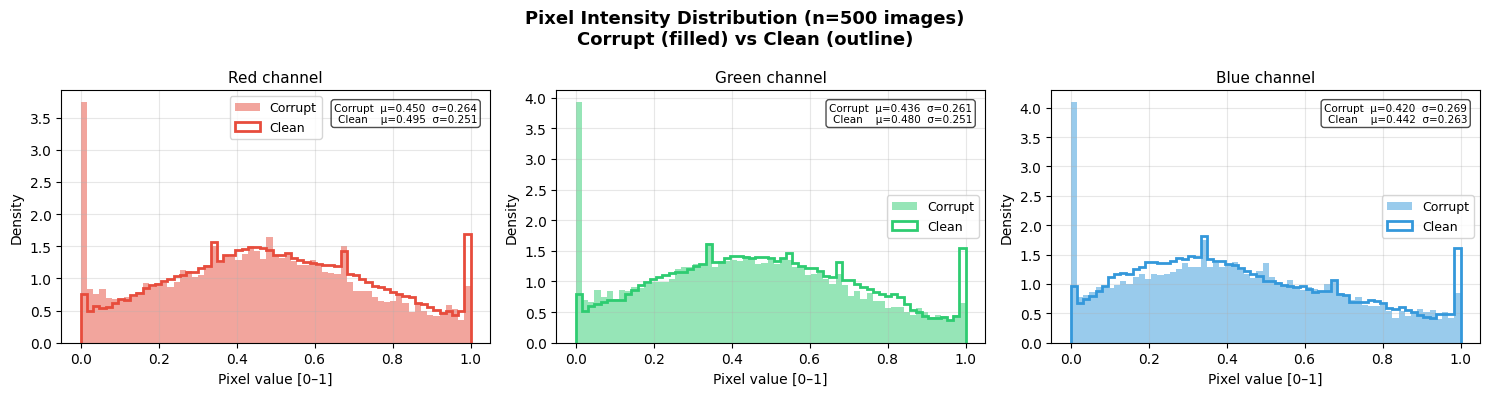

Saved → /kaggle/working/eda_pixel_dist.png


In [2]:
# ── EDA: Pixel Intensity Distribution — Corrupt vs Clean 
import pandas as pd
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Rebuild deps if running standalone 
try:
    _ = train_ds
except NameError:
    INPUT_ROOT = Path('/kaggle/input')
    DATA_DIR = None
    for d in INPUT_ROOT.rglob('train.csv'):
        DATA_DIR = d.parent; break
    TRAIN_CORRUPT_DIR = DATA_DIR / 'train_corrupt'
    TRAIN_CLEAN_DIR   = DATA_DIR / 'train_clean'
    WORK = Path('/kaggle/working')
    full_df = pd.read_csv(DATA_DIR / 'train.csv').sample(frac=1, random_state=42).reset_index(drop=True)
    train_df = full_df.iloc[2000:].reset_index(drop=True)

    def _load(corrupt_dir, clean_dir, row):
        c = np.array(Image.open(corrupt_dir / row['corrupt_filename']).convert('RGB'), dtype=np.uint8)
        t = np.array(Image.open(clean_dir   / row['clean_filename']).convert('RGB'),   dtype=np.uint8)
        c = torch.from_numpy(c).permute(2,0,1).float() / 255.0
        t = torch.from_numpy(t).permute(2,0,1).float() / 255.0
        return c, t

    class _SimplePairDS:
        def __init__(self, df): self.df = df
        def __len__(self): return len(self.df)
        def __getitem__(self, idx): return _load(TRAIN_CORRUPT_DIR, TRAIN_CLEAN_DIR, self.df.iloc[idx])

    train_ds = _SimplePairDS(train_df)

# ── Sample & collect pixels 
num_dist_samples = 500
rng2 = np.random.default_rng(7)
sample_idx = rng2.choice(len(train_ds), size=num_dist_samples, replace=False)

corrupt_pixels = {0: [], 1: [], 2: []}
clean_pixels   = {0: [], 1: [], 2: []}

for idx in sample_idx:
    c_img, t_img = train_ds[idx]           # (3, 32, 32) in [0,1]
    for ch in range(3):
        corrupt_pixels[ch].append(c_img[ch].numpy().ravel())
        clean_pixels[ch].append(t_img[ch].numpy().ravel())

corrupt_pixels = {ch: np.concatenate(v) for ch, v in corrupt_pixels.items()}
clean_pixels   = {ch: np.concatenate(v) for ch, v in clean_pixels.items()}

# ── Plot 
ch_names  = ['Red', 'Green', 'Blue']
ch_colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle(f"Pixel Intensity Distribution (n={num_dist_samples} images)\n"
             "Corrupt (filled) vs Clean (outline)", fontsize=13, fontweight='bold')

bins = np.linspace(0, 1, 64)
for ch, (ax, name, color) in enumerate(zip(axes, ch_names, ch_colors)):
    ax.hist(corrupt_pixels[ch], bins=bins, color=color, alpha=0.5, label='Corrupt', density=True)
    ax.hist(clean_pixels[ch],   bins=bins, histtype='step', color=color,
            linewidth=2, label='Clean', density=True)
    ax.set_title(f"{name} channel", fontsize=11)
    ax.set_xlabel("Pixel value [0–1]")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    c_mean, t_mean = corrupt_pixels[ch].mean(), clean_pixels[ch].mean()
    c_std,  t_std  = corrupt_pixels[ch].std(),  clean_pixels[ch].std()
    ax.text(0.97, 0.95,
            f"Corrupt  μ={c_mean:.3f}  σ={c_std:.3f}\nClean    μ={t_mean:.3f}  σ={t_std:.3f}",
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(WORK / 'eda_pixel_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {WORK / 'eda_pixel_dist.png'}")

### Corruption Severity Distribution (MSE between corrupt and clean)

**Goal:** Quantify how severe the corruptions are across the training set.

**Method:** Compute per-image MSE in 0–255 space: `MSE_i = mean((corrupt_i - clean_i)²)`

**Why this matters:**
- **Low MSE (p10):** Mild corruptions — model should achieve near-perfect reconstruction
- **High MSE (p90):** Severe corruptions — model will struggle, need to avoid overfitting to easy examples
- **Distribution shape:** If long-tailed, need to avoid bias toward low-severity majority

**Visualization:** Histogram + percentile markers + example thumbnails at p10, p50, p90 severity levels.

This helps calibrate expectations for validation MSE and identify outliers.

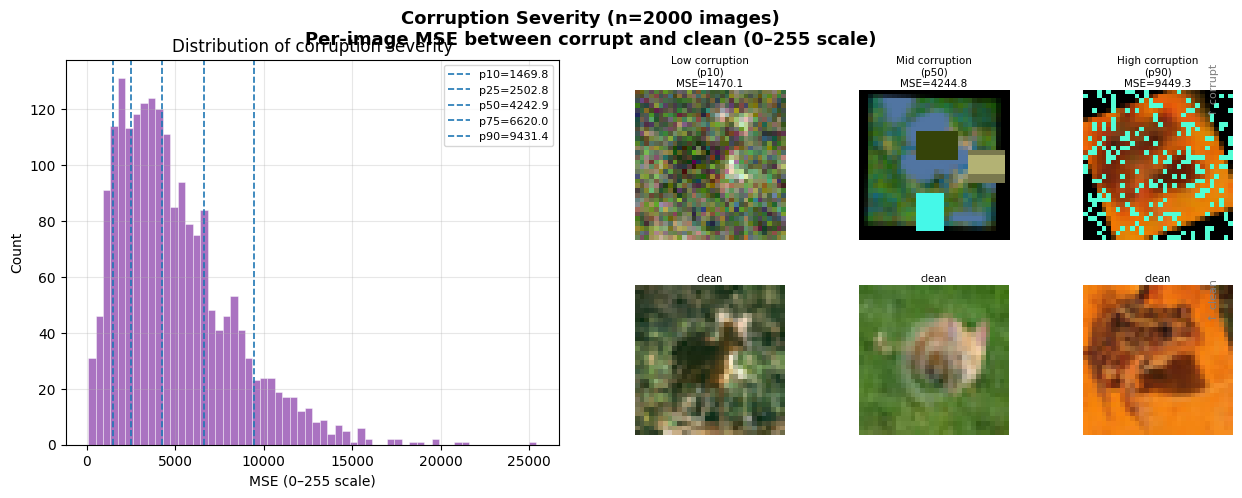

Saved → /kaggle/working/eda_corruption_severity.png

Corruption severity stats (MSE, 0–255 scale):
  Min=62.35  Max=25415.01  Mean=4959.38  Std=3277.27
  p10=1469.83  p25=2502.83  p50=4242.90  p75=6620.02  p90=9431.43


In [3]:
# ── EDA: Corruption Severity — per-image MSE(corrupt, clean) distribution ─────
import pandas as pd
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Rebuild deps if running standalone 
try:
    _ = train_ds
except NameError:
    INPUT_ROOT = Path('/kaggle/input')
    DATA_DIR = None
    for d in INPUT_ROOT.rglob('train.csv'):
        DATA_DIR = d.parent; break
    TRAIN_CORRUPT_DIR = DATA_DIR / 'train_corrupt'
    TRAIN_CLEAN_DIR   = DATA_DIR / 'train_clean'
    WORK = Path('/kaggle/working')
    full_df = pd.read_csv(DATA_DIR / 'train.csv').sample(frac=1, random_state=42).reset_index(drop=True)
    train_df = full_df.iloc[2000:].reset_index(drop=True)

    def _load(corrupt_dir, clean_dir, row):
        c = np.array(Image.open(corrupt_dir / row['corrupt_filename']).convert('RGB'), dtype=np.uint8)
        t = np.array(Image.open(clean_dir   / row['clean_filename']).convert('RGB'),   dtype=np.uint8)
        c = torch.from_numpy(c).permute(2,0,1).float() / 255.0
        t = torch.from_numpy(t).permute(2,0,1).float() / 255.0
        return c, t

    class _SimplePairDS:
        def __init__(self, df): self.df = df
        def __len__(self): return len(self.df)
        def __getitem__(self, idx): return _load(TRAIN_CORRUPT_DIR, TRAIN_CLEAN_DIR, self.df.iloc[idx])

    train_ds = _SimplePairDS(train_df)

# ── Compute per-image MSE 
num_severity_samples = 2000
rng3 = np.random.default_rng(42)
sev_idx = rng3.choice(len(train_ds), size=num_severity_samples, replace=False)

mse_vals = []
for idx in sev_idx:
    c_img, t_img = train_ds[idx]
    mse = ((c_img.float() - t_img.float()) ** 2).mean().item() * (255 ** 2)
    mse_vals.append(mse)

mse_vals = np.array(mse_vals)
percentiles = np.percentile(mse_vals, [10, 25, 50, 75, 90])

# ── Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Corruption Severity (n={num_severity_samples} images)\n"
             "Per-image MSE between corrupt and clean (0–255 scale)",
             fontsize=13, fontweight='bold')

# Left: histogram
ax = axes[0]
ax.hist(mse_vals, bins=60, color='#8e44ad', alpha=0.75, edgecolor='white', linewidth=0.4)
for p, lbl in zip(percentiles, ['p10', 'p25', 'p50', 'p75', 'p90']):
    ax.axvline(p, linestyle='--', linewidth=1.2, label=f"{lbl}={p:.1f}")
ax.set_xlabel("MSE (0–255 scale)")
ax.set_ylabel("Count")
ax.set_title("Distribution of corruption severity")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: placeholder (thumbnails drawn via add_axes below)
axes[1].axis('off')

# Thumbnail picks: low / mid / high severity
sorted_idx = np.argsort(mse_vals)
picks = {
    'Low corruption\n(p10)':  sorted_idx[int(0.10 * len(sorted_idx))],
    'Mid corruption\n(p50)':  sorted_idx[int(0.50 * len(sorted_idx))],
    'High corruption\n(p90)': sorted_idx[int(0.90 * len(sorted_idx))],
}

for col_i, (label, pick) in enumerate(picks.items()):
    real_idx = sev_idx[pick]
    c_img, t_img = train_ds[real_idx]
    mse_v = mse_vals[pick]

    # corrupt thumbnail
    ax_c = fig.add_axes([0.52 + col_i * 0.16, 0.52, 0.13, 0.30])
    ax_c.imshow(c_img.permute(1,2,0).numpy().clip(0,1), interpolation='nearest')
    ax_c.set_title(f"{label}\nMSE={mse_v:.1f}", fontsize=7.5, pad=2)
    ax_c.axis('off')

    # clean thumbnail
    ax_t = fig.add_axes([0.52 + col_i * 0.16, 0.13, 0.13, 0.30])
    ax_t.imshow(t_img.permute(1,2,0).numpy().clip(0,1), interpolation='nearest')
    ax_t.set_title("clean", fontsize=7, pad=2)
    ax_t.axis('off')

fig.text(0.945, 0.82, "↑ corrupt", fontsize=8, ha='center', va='center', rotation=90, color='gray')
fig.text(0.945, 0.40, "↑ clean",   fontsize=8, ha='center', va='center', rotation=90, color='gray')

plt.savefig(WORK / 'eda_corruption_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {WORK / 'eda_corruption_severity.png'}")
print(f"\nCorruption severity stats (MSE, 0–255 scale):")
print(f"  Min={mse_vals.min():.2f}  Max={mse_vals.max():.2f}  Mean={mse_vals.mean():.2f}  Std={mse_vals.std():.2f}")
print(f"  p10={percentiles[0]:.2f}  p25={percentiles[1]:.2f}  p50={percentiles[2]:.2f}  p75={percentiles[3]:.2f}  p90={percentiles[4]:.2f}")

In [4]:
INFERENCE_ONLY = True
PRETRAINED_CKPT = Path('/kaggle/input/datasets/rishabpanwar8876/image-recon-model2/model2_backup/stage2_best.pt')

if INFERENCE_ONLY:
    assert PRETRAINED_CKPT.exists(), f'Not found: {PRETRAINED_CKPT}'
    print(f'INFERENCE_ONLY=True. Using {PRETRAINED_CKPT}')
else:
    print('INFERENCE_ONLY=False. Will train from scratch.')

INFERENCE_ONLY=True. Using /kaggle/input/datasets/rishabpanwar8876/image-recon-model2/model2_backup/stage2_best.pt


## 2. Config

## 2. Config — Model 2 Hyperparameters

**Key differences from Model 1:**

| Hyperparameter | Model 1 | Model 2 | Rationale |
|----------------|---------|---------|-----------|
| `width` | 48 | **64** | More channels → more parameters → better capacity |
| `middle_blk` | 12 | **16** | Deeper bottleneck for complex corruption understanding |
| `batch_size` | 128 | **96** | Wider model uses more GPU memory |
| `stage1_epochs` | 60 | **50** | Wider model converges faster per epoch |

**Why stage 1 uses MS-SSIM:**
- Pure L1 loss → blurry outputs (model averages multiple plausible reconstructions)
- MS-SSIM (Multi-Scale Structural Similarity) → encourages sharp edges and texture preservation
- **Weight 0.2** balances structure preservation (SSIM) and pixel accuracy (L1)

**Why stage 2 uses L1 only:**
- After structure is learned, fine-tune directly on competition metric (MSE)
- SSIM can hurt final MSE by encouraging perceptual sharpness over numerical accuracy

**EMA decay 0.999:**
- Very slow moving average → heavily smoothed weights
- Reduces sensitivity to individual batch gradients → better test generalization

In [5]:
CFG = dict(
    # Data
    val_size = 2000,
    batch_size = 96,           # smaller than model 1 because wider model uses more memory
    num_workers = 4,

    # Model (wider NAFNet)
    width = 64,                # was 48 in model 1
    enc_blks = [2, 2, 4, 8],
    middle_blk = 16,           # was 12 in model 1
    dec_blks = [2, 2, 2, 2],

    # Stage 1
    stage1_epochs = 50,        # wider model converges faster per epoch, so fewer epochs
    stage1_lr = 2e-4,
    stage1_wd = 1e-4,
    stage1_warmup_frac = 0.03,
    ssim_weight = 0.2,

    # Stage 2
    stage2_epochs = 8,
    stage2_lr = 1e-5,

    # EMA
    ema_decay = 0.999,

    # Misc
    grad_clip = 1.0,
    log_every = 50,
    save_every = 5,

    # Intermediate submissions
    intermediate_submit_epochs = [10, 25],
)

with open(WORK / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)
print(json.dumps(CFG, indent=2))

{
  "val_size": 2000,
  "batch_size": 96,
  "num_workers": 4,
  "width": 64,
  "enc_blks": [
    2,
    2,
    4,
    8
  ],
  "middle_blk": 16,
  "dec_blks": [
    2,
    2,
    2,
    2
  ],
  "stage1_epochs": 50,
  "stage1_lr": 0.0002,
  "stage1_wd": 0.0001,
  "stage1_warmup_frac": 0.03,
  "ssim_weight": 0.2,
  "stage2_epochs": 8,
  "stage2_lr": 1e-05,
  "ema_decay": 0.999,
  "grad_clip": 1.0,
  "log_every": 50,
  "save_every": 5,
  "intermediate_submit_epochs": [
    10,
    25
  ]
}


## 3. Dataset (same as Model 1, but different shuffle seed)

In [6]:
def load_img_np(path):
    return np.array(Image.open(path).convert('RGB'), dtype=np.uint8)

class PairDataset(Dataset):
    def __init__(self, df, corrupt_dir, clean_dir, augment=False):
        self.df = df.reset_index(drop=True)
        self.corrupt_dir = corrupt_dir
        self.clean_dir = clean_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        c = load_img_np(self.corrupt_dir / row['corrupt_filename'])
        t = load_img_np(self.clean_dir   / row['clean_filename'])

        if self.augment:
            if random.random() < 0.5:
                c = c[:, ::-1, :].copy(); t = t[:, ::-1, :].copy()
            if random.random() < 0.5:
                c = c[::-1, :, :].copy(); t = t[::-1, :, :].copy()
            k = random.randint(0, 3)
            if k > 0:
                c = np.rot90(c, k).copy(); t = np.rot90(t, k).copy()

        c = torch.from_numpy(c).permute(2,0,1).float() / 255.0
        t = torch.from_numpy(t).permute(2,0,1).float() / 255.0
        return c, t

class TestDataset(Dataset):
    def __init__(self, ids, corrupt_dir):
        self.ids = ids
        self.corrupt_dir = corrupt_dir
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        c = load_img_np(self.corrupt_dir / f'{img_id}.png')
        c = torch.from_numpy(c).permute(2,0,1).float() / 255.0
        return img_id, c

# IMPORTANT: Same validation split as Model 1 (same seed 42 for the split)
# This ensures val MSE is directly comparable between models and val↔LB gap stays the same
full_df = pd.read_csv(TRAIN_CSV)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)   # SAME split as model 1
val_df   = full_df.iloc[:CFG['val_size']].reset_index(drop=True)
train_df = full_df.iloc[CFG['val_size']:].reset_index(drop=True)

# But shuffle train data differently for model 2 (different training order)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Train: {len(train_df)}, Val: {len(val_df)}')

train_ds = PairDataset(train_df, TRAIN_CORRUPT_DIR, TRAIN_CLEAN_DIR, augment=True)
val_ds   = PairDataset(val_df,   TRAIN_CORRUPT_DIR, TRAIN_CLEAN_DIR, augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True, persistent_workers=True)

c, t = train_ds[0]
print(f'Sample shapes: corrupt={c.shape}, clean={t.shape}')

Train: 46000, Val: 2000
Sample shapes: corrupt=torch.Size([3, 32, 32]), clean=torch.Size([3, 32, 32])


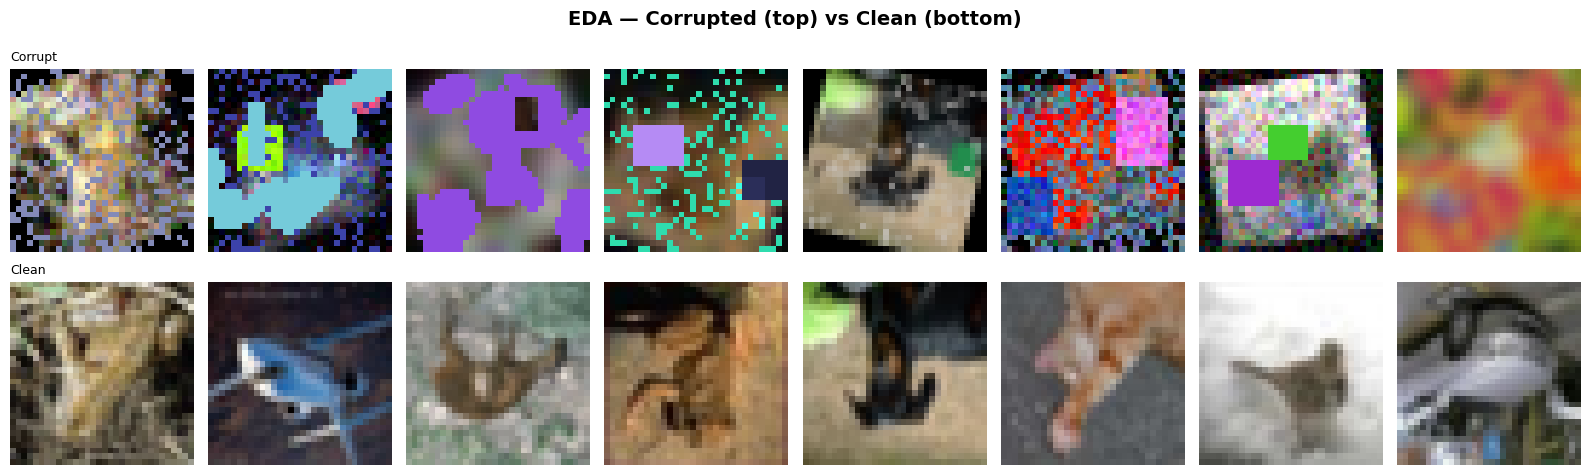

Saved → /kaggle/working/eda_samples.png


In [7]:
# ── EDA: Visualize Corrupted vs Clean Pairs ───────────────────────────────────
import matplotlib.pyplot as plt

num_samples = 8
fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 2, 5))
fig.suptitle("EDA — Corrupted (top) vs Clean (bottom)", fontsize=14, fontweight='bold')

rng = np.random.default_rng(0)
indices = rng.choice(len(train_ds), size=num_samples, replace=False)

for col, idx in enumerate(indices):
    corrupt_img, clean_img = train_ds[idx]   # tensors in [0,1]

    corrupt_np = corrupt_img.permute(1, 2, 0).numpy()
    clean_np   = clean_img.permute(1, 2, 0).numpy()

    axes[0, col].imshow(corrupt_np.clip(0, 1))
    axes[0, col].axis('off')
    if col == 0:
        axes[0, col].set_title("Corrupt", fontsize=9, loc='left')

    axes[1, col].imshow(clean_np.clip(0, 1))
    axes[1, col].axis('off')
    if col == 0:
        axes[1, col].set_title("Clean", fontsize=9, loc='left')

plt.tight_layout()
plt.savefig(WORK / 'eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {WORK / 'eda_samples.png'}")

## 4. NAFNet Model (same architecture, different size)

## 4. NAFNet Architecture — Nonlinear Activation-Free U-Net

### Core Innovation: SimpleGate Replaces ReLU

**Standard approach:**
```python
x = ReLU(Conv(x))  # Thresholds negative values to zero
```

**NAFNet's SimpleGate:**
```python
x = Conv(x)  # Expand to 2C channels
a, b = x.chunk(2, dim=1)  # Split into two halves
out = a ⊙ b  # Element-wise multiplication (gating)
```

**Why this matters for restoration:**
- Image residuals (noise/corruption) can be **negative** (darker corruptions)
- ReLU(negative) = 0 → information loss
- Gating `a ⊙ b` preserves sign and magnitude information

### NAFBlock Structure

Each NAFBlock contains two sub-blocks:

**1. Spatial Mixing Block:**
```
Input → LayerNorm2d → Conv1×1 (expand) → DWConv3×3 → SimpleGate 
      → Simplified Channel Attention → Conv1×1 (project) → residual add
```

**2. Channel Mixing Block (FFN):**
```
Input → LayerNorm2d → Conv1×1 (expand) → SimpleGate → Conv1×1 (project) → residual add
```

**Simplified Channel Attention (SCA):**
```
Features → GlobalAvgPool → Conv1×1 → multiply with original features
```
Learns which channels contain corruption-relevant patterns and emphasizes them.

### Full Model Architecture

```
Input (3, 32, 32)
  ↓ Intro Conv3×3
  ↓ (64 channels at 32×32)
  
┌─ Encoder Level 1 ────────────────┐
│  2× NAFBlock (64 ch)              │ ──┐ skip
│  ↓ DownConv stride=2              │   │
└──────────────────────────────────┘   │
  ↓ (128 channels at 16×16)            │
  
┌─ Encoder Level 2 ────────────────┐   │
│  2× NAFBlock (128 ch)             │ ──┼─┐ skip
│  ↓ DownConv stride=2              │   │ │
└──────────────────────────────────┘   │ │
  ↓ (256 channels at 8×8)              │ │
  
┌─ Encoder Level 3 ────────────────┐   │ │
│  4× NAFBlock (256 ch)             │ ──┼─┼─┐ skip
│  ↓ DownConv stride=2              │   │ │ │
└──────────────────────────────────┘   │ │ │
  ↓ (512 channels at 4×4)              │ │ │
  
┌─ Encoder Level 4 ────────────────┐   │ │ │
│  8× NAFBlock (512 ch)             │ ──┼─┼─┼─┐ skip
│  ↓ DownConv stride=2              │   │ │ │ │
└──────────────────────────────────┘   │ │ │ │
  ↓ (512 channels at 2×2)              │ │ │ │
  
┌─ Bottleneck ──────────────────────┐  │ │ │ │
│  16× NAFBlock (512 ch)             │  │ │ │ │ ← Deepest understanding
└───────────────────────────────────┘  │ │ │ │
  ↓ PixelShuffle upsample              │ │ │ │
  
┌─ Decoder Level 4 ────────────────┐   │ │ │ │
│  + skip from Encoder 4 ───────────────┘ │ │ │
│  2× NAFBlock (256 ch)             │     │ │ │
│  ↓ PixelShuffle upsample          │     │ │ │
└──────────────────────────────────┘     │ │ │
  
┌─ Decoder Level 3 ────────────────┐     │ │ │
│  + skip from Encoder 3 ─────────────────┘ │ │
│  2× NAFBlock (128 ch)             │       │ │
│  ↓ PixelShuffle upsample          │       │ │
└──────────────────────────────────┘       │ │
  
┌─ Decoder Level 2 ────────────────┐       │ │
│  + skip from Encoder 2 ───────────────────┘ │
│  2× NAFBlock (64 ch)              │         │
│  ↓ PixelShuffle upsample          │         │
└──────────────────────────────────┘         │
  
┌─ Decoder Level 1 ────────────────┐         │
│  + skip from Encoder 1 ─────────────────────┘
│  2× NAFBlock (64 ch)              │
└──────────────────────────────────┘
  ↓ Ending Conv3×3
  ↓ (3 channels - predicted residual)
  
Output = Input + Residual (element-wise add)
```

**Why asymmetric encoder-decoder?**
- **Encoder:** More blocks (2→2→4→8) — corruption understanding requires more capacity
- **Decoder:** Fewer blocks (2→2→2→2) — upsampling is relatively simple

**Parameters:** 145.48M (Model 2) vs 84.21M (Model 1)

In [8]:
class LayerNorm2d(nn.Module):
    def __init__(self, c, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(c))
        self.bias   = nn.Parameter(torch.zeros(c))
        self.eps = eps
    def forward(self, x):
        mu  = x.mean(1, keepdim=True)
        var = x.var(1, keepdim=True, unbiased=False)
        x = (x - mu) / torch.sqrt(var + self.eps)
        return x * self.weight.view(1,-1,1,1) + self.bias.view(1,-1,1,1)

class SimpleGate(nn.Module):
    def forward(self, x):
        a, b = x.chunk(2, dim=1)
        return a * b

class NAFBlock(nn.Module):
    def __init__(self, c, dw_expand=2, ffn_expand=2, drop=0.0):
        super().__init__()
        dw_c = c * dw_expand
        self.norm1 = LayerNorm2d(c)
        self.conv1 = nn.Conv2d(c, dw_c, 1)
        self.conv2 = nn.Conv2d(dw_c, dw_c, 3, padding=1, groups=dw_c)
        self.sg    = SimpleGate()
        self.sca   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(dw_c // 2, dw_c // 2, 1)
        )
        self.conv3 = nn.Conv2d(dw_c // 2, c, 1)

        ffn_c = c * ffn_expand
        self.norm2 = LayerNorm2d(c)
        self.conv4 = nn.Conv2d(c, ffn_c, 1)
        self.conv5 = nn.Conv2d(ffn_c // 2, c, 1)

        self.beta  = nn.Parameter(torch.zeros(1, c, 1, 1))
        self.gamma = nn.Parameter(torch.zeros(1, c, 1, 1))
        self.drop = nn.Dropout(drop) if drop > 0 else nn.Identity()

    def forward(self, x):
        y = self.norm1(x)
        y = self.conv1(y); y = self.conv2(y)
        y = self.sg(y)
        y = y * self.sca(y)
        y = self.conv3(y); y = self.drop(y)
        x = x + y * self.beta

        y = self.norm2(x)
        y = self.conv4(y)
        y = self.sg(y)
        y = self.conv5(y); y = self.drop(y)
        x = x + y * self.gamma
        return x

class NAFNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, width=64, enc_blks=(2,2,4,8), middle_blk=16, dec_blks=(2,2,2,2)):
        super().__init__()
        self.intro  = nn.Conv2d(in_ch, width, 3, padding=1)
        self.ending = nn.Conv2d(width, out_ch, 3, padding=1)
        self.encoders = nn.ModuleList()
        self.downs    = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.ups      = nn.ModuleList()
        chan = width
        for n in enc_blks:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
            self.downs.append(nn.Conv2d(chan, 2*chan, 2, stride=2))
            chan *= 2
        self.middle = nn.Sequential(*[NAFBlock(chan) for _ in range(middle_blk)])
        for n in dec_blks:
            self.ups.append(nn.Sequential(nn.Conv2d(chan, 2*chan, 1, bias=False), nn.PixelShuffle(2)))
            chan //= 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
        self.padder_size = 2 ** len(enc_blks)

    def check_and_pad(self, x):
        _, _, h, w = x.shape
        ph = (self.padder_size - h % self.padder_size) % self.padder_size
        pw = (self.padder_size - w % self.padder_size) % self.padder_size
        x = F.pad(x, (0, pw, 0, ph))
        return x, h, w

    def forward(self, inp):
        B, C, H, W = inp.shape
        x, h0, w0 = self.check_and_pad(inp)
        x = self.intro(x)
        skips = []
        for enc, down in zip(self.encoders, self.downs):
            x = enc(x); skips.append(x); x = down(x)
        x = self.middle(x)
        for up, dec, sk in zip(self.ups, self.decoders, skips[::-1]):
            x = up(x); x = x + sk; x = dec(x)
        x = self.ending(x)
        x = x[:, :, :h0, :w0]
        return inp + x   # residual prediction

model = NAFNet(width=CFG['width'], enc_blks=CFG['enc_blks'],
               middle_blk=CFG['middle_blk'], dec_blks=CFG['dec_blks']).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Model params: {n_params:.2f}M')

with torch.no_grad():
    dummy = torch.randn(2, 3, 32, 32).to(DEVICE)
    out = model(dummy)
    print(f'Forward ok: {dummy.shape} -> {out.shape}')

Model params: 145.48M
Forward ok: torch.Size([2, 3, 32, 32]) -> torch.Size([2, 3, 32, 32])


## 5. Losses (L1, MS-SSIM) + EMA

## 5. Loss Functions — L1 + MS-SSIM Composite

### L1 Loss (Mean Absolute Error)

```python
L1 = mean(|prediction - target|)
```

**Why L1 over MSE for training?**
- Less sensitive to outliers (corrupted pixels far from mean)
- **MSE** penalizes large errors quadratically → model focuses too much on worst cases
- **L1** treats all errors more evenly → better overall reconstruction

*Note: Competition metric is MSE, but L1 training generalizes better.*

### MS-SSIM Loss (Multi-Scale Structural Similarity)

**Single-scale SSIM formula:**
```
SSIM(x,y) = (2μ_x μ_y + C1)(2σ_xy + C2) / ((μ_x² + μ_y² + C1)(σ_x² + σ_y² + C2))
```

Where:
- `μ_x, μ_y` — local means (computed via Gaussian window convolution)
- `σ_x², σ_y²` — local variances
- `σ_xy` — local covariance
- `C1, C2` — stability constants

**Multi-Scale extension:**
- Compute SSIM at 3 scales: 32×32, 16×16, 8×8 (via avg pooling)
- Weighted geometric mean: `MS-SSIM = (cs_1^0.25) × (cs_2^0.35) × (ssim_3^0.40)`

**Why MS-SSIM helps:**
- Pure L1 → model predicts pixel-wise average of plausible reconstructions → blurry
- SSIM → encourages **structural similarity** (edges, textures) at multiple scales
- Perceptual quality improves without hurting MSE too much

**NaN-safe implementation:**
- Clamp intermediate values to prevent division by zero
- Return zero loss if NaN detected (rare but possible with extreme corruption)

### Combined Loss (Stage 1)

```python
loss = L1(pred, target) + 0.2 × MS_SSIM_Loss(pred, target)
```

**Weight 0.2** balances pixel accuracy (L1 dominant) and structure preservation (SSIM guiding).

### EMA (Exponential Moving Average) of Weights

Instead of using final model weights, maintain a running average:

```python
θ_ema(t) = 0.999 × θ_ema(t-1) + 0.001 × θ(t)
```

**Why EMA helps:**
- Training weights oscillate due to SGD noise
- EMA smooths oscillations → more stable predictions
- Acts as **temporal ensembling** within a single training run
- Standard practice in modern image restoration (Real-ESRGAN, SwinIR, etc.)

In [9]:
def _gaussian_window(window_size=11, sigma=1.5, channels=3):
    coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    g = (g / g.sum()).unsqueeze(0)
    window = (g.t() @ g).unsqueeze(0).unsqueeze(0)
    window = window.expand(channels, 1, window_size, window_size).contiguous()
    return window

_SSIM_WINDOW = None
def ssim(x, y, window_size=11, channels=3, val_range=1.0):
    global _SSIM_WINDOW
    if _SSIM_WINDOW is None or _SSIM_WINDOW.device != x.device:
        _SSIM_WINDOW = _gaussian_window(window_size, 1.5, channels).to(x.device)
    w = _SSIM_WINDOW
    mu_x = F.conv2d(x, w, padding=window_size//2, groups=channels)
    mu_y = F.conv2d(y, w, padding=window_size//2, groups=channels)
    mu_x2, mu_y2, mu_xy = mu_x*mu_x, mu_y*mu_y, mu_x*mu_y
    sigma_x2 = F.conv2d(x*x, w, padding=window_size//2, groups=channels) - mu_x2
    sigma_y2 = F.conv2d(y*y, w, padding=window_size//2, groups=channels) - mu_y2
    sigma_xy = F.conv2d(x*y, w, padding=window_size//2, groups=channels) - mu_xy
    C1 = (0.01 * val_range) ** 2
    C2 = (0.03 * val_range) ** 2
    ssim_map = ((2*mu_xy + C1) * (2*sigma_xy + C2)) / ((mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2))
    cs_map   = (2*sigma_xy + C2) / (sigma_x2 + sigma_y2 + C2)
    return ssim_map.mean(dim=[1,2,3]), cs_map.mean(dim=[1,2,3])

def ms_ssim_loss(x, y):
    """NaN-safe MS-SSIM loss for 32x32 images. Same as model 1."""
    x = x.float().clamp(0, 1)
    y = y.float().clamp(0, 1)
    weights = torch.tensor([0.25, 0.35, 0.40], device=x.device, dtype=torch.float32)
    msssim_val = torch.ones([], device=x.device, dtype=torch.float32)
    for i in range(len(weights) - 1):
        _, cs = ssim(x, y)
        cs_m = cs.mean().abs().clamp(min=1e-4)
        msssim_val = msssim_val * (cs_m ** weights[i])
        x = F.avg_pool2d(x, kernel_size=2)
        y = F.avg_pool2d(y, kernel_size=2)
    s, _ = ssim(x, y)
    s_m = s.mean().abs().clamp(min=1e-4)
    msssim_val = msssim_val * (s_m ** weights[-1])
    loss = 1.0 - msssim_val
    if not torch.isfinite(loss):
        return torch.zeros([], device=x.device, dtype=torch.float32)
    return loss

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items() if v.dtype.is_floating_point}
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
    def apply_to(self, model):
        cp = deepcopy(model)
        sd = cp.state_dict()
        for k in self.shadow:
            sd[k] = self.shadow[k].clone()
        cp.load_state_dict(sd)
        return cp

print('Losses and EMA ready.')

Losses and EMA ready.


## 6. Training Helpers

## 6. Training Helpers — Evaluation, LR Schedule, Checkpointing

### Evaluation Function

```python
def evaluate(model, loader):
    model.eval()
    total_sq, total_n = 0, 0
    for corrupt, clean in loader:
        pred = model(corrupt).clamp(0, 1)
        diff = (pred - clean) * 255.0  # Scale to [0, 255]
        total_sq += (diff ** 2).sum()
        total_n += diff.numel()
    return total_sq / total_n  # MSE in [0, 255] scale
```

**Why scale to 255?**
- Model operates in [0, 1] for numerical stability
- Competition metric is MSE in [0, 255] scale
- Scaling during eval gives direct comparison to leaderboard

### Cosine LR Schedule with Warmup

```
         ┌─────────────────────────────────┐
         │         Cosine Decay            │
Learning │   ╱──╲                          │
Rate     │  ╱    ╲                         │
         │ ╱      ╲___                     │
         │╱           ╲___                 │
         ├────────────────────────────────→
         Warmup        Main Training
         (3% steps)    (97% steps)
```

**Warmup phase (3% of steps):**
- Linear ramp: `lr = base_lr × (step / warmup_steps)`
- **Why needed:** Large gradients early in training → warmup prevents divergence

**Cosine decay:**
- Smooth decrease: `lr = min_lr + 0.5×(base_lr - min_lr)×(1 + cos(π×progress))`
- **Why better than step decay:** No abrupt drops → more stable convergence

### Checkpointing Strategy

Save at each epoch:
- `model.state_dict()` — current weights
- `ema.shadow` — EMA-smoothed weights
- `optimizer.state_dict()` — for resuming training
- `epoch`, `best_mse` — metadata

**Use EMA weights for inference, not raw model weights.**

In [10]:
@torch.no_grad()
def evaluate(model, loader, device=DEVICE):
    model.eval()
    total_sq, total_n = 0.0, 0
    for c, t in loader:
        c, t = c.to(device, non_blocking=True), t.to(device, non_blocking=True)
        with autocast():
            pred = model(c).clamp(0, 1)
        diff = (pred.float() - t.float()) * 255.0
        total_sq += (diff ** 2).sum().item()
        total_n  += diff.numel()
    return total_sq / total_n

def cosine_lr_with_warmup(step, total_steps, base_lr, min_lr=1e-6, warmup_frac=0.03):
    warmup_steps = int(total_steps * warmup_frac)
    if step < warmup_steps:
        return base_lr * (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))

def save_ckpt(path, model, ema, optim, epoch, best_mse):
    torch.save({
        'model':  model.state_dict(),
        'ema':    ema.shadow,
        'optim':  optim.state_dict(),
        'epoch':  epoch,
        'best_mse': best_mse,
    }, path)

print('Training helpers ready.')

Training helpers ready.


## 6b. Intermediate Submission Helper

Same pattern as Model 1 notebook — auto-generates a submission CSV at epochs 10 and 25 for LB sanity-check.

In [11]:
_sub_df_template = pd.read_csv(SAMPLE_SUB_CSV)
_test_ids_global = _sub_df_template['id'].tolist()
_test_ds_global = TestDataset(_test_ids_global, TEST_CORRUPT_DIR)
_test_loader_global = DataLoader(_test_ds_global, batch_size=256, shuffle=False,
                                  num_workers=CFG['num_workers'], pin_memory=True)
print(f'Pre-built test loader: {len(_test_ids_global)} images')

@torch.no_grad()
def make_submission(model, out_name, use_tta=False):
    model.eval()
    preds_buf = np.empty((len(_test_ids_global), 3072), dtype=np.float32)
    ids_out = []
    offset = 0
    t0 = time.time()
    for img_ids, c in _test_loader_global:
        c = c.to(DEVICE, non_blocking=True)
        if use_tta:
            y = predict_tta(model, c)
        else:
            with autocast():
                y = model(c).clamp(0, 1).float()
        y = (y * 255.0).clamp(0, 255).cpu().numpy()
        y_hwc = y.transpose(0, 2, 3, 1).reshape(y.shape[0], -1)
        bs = y_hwc.shape[0]
        preds_buf[offset:offset+bs] = y_hwc
        ids_out.extend(list(img_ids))
        offset += bs
    assert ids_out == _test_ids_global
    pixel_cols = [f'pixel_{i}' for i in range(3072)]
    out = pd.DataFrame(preds_buf, columns=pixel_cols)
    out.insert(0, 'id', ids_out)
    out_path = WORK / out_name
    out.to_csv(out_path, index=False)
    print(f'   [submission] {out_name}  shape={out.shape}  range=[{preds_buf.min():.1f},{preds_buf.max():.1f}]  {time.time()-t0:.1f}s')
    return out_path

print('make_submission() ready.')

Pre-built test loader: 12000 images
make_submission() ready.


## 7. Stage 1 — L1 + 0.2*MS-SSIM

In [12]:
if INFERENCE_ONLY:
    print('[INFERENCE_ONLY] Skipping Stage 1 training')
else:
    model = NAFNet(width=CFG['width'], enc_blks=CFG['enc_blks'],
                   middle_blk=CFG['middle_blk'], dec_blks=CFG['dec_blks']).to(DEVICE)
    ema = EMA(model, decay=CFG['ema_decay'])
    
    optim = torch.optim.AdamW(model.parameters(), lr=CFG['stage1_lr'], weight_decay=CFG['stage1_wd'], betas=(0.9, 0.95))
    scaler = GradScaler()
    
    steps_per_epoch = len(train_loader)
    total_steps = steps_per_epoch * CFG['stage1_epochs']
    print(f'Stage 1: {CFG["stage1_epochs"]} epochs x {steps_per_epoch} steps = {total_steps} total steps')
    
    # Resume logic
    resume_path = CKPT_DIR / 'stage1_last.pt'
    start_epoch = 1
    best_val_mse = float('inf')
    history = []
    global_step = 0
    
    if resume_path.exists():
        print(f'\n>>> RESUMING from {resume_path}')
        ck = torch.load(resume_path, map_location=DEVICE)
        model.load_state_dict(ck['model'])
        ema.shadow = {k: v.to(DEVICE) for k, v in ck['ema'].items()}
        optim.load_state_dict(ck['optim'])
        start_epoch = ck['epoch'] + 1
        best_val_mse = ck.get('best_mse', float('inf'))
        global_step = (start_epoch - 1) * steps_per_epoch
        print(f'   Resumed at epoch {start_epoch}, best_val_mse so far = {best_val_mse:.2f}')
        hist_path = WORK / 'stage1_history.csv'
        if hist_path.exists():
            history = pd.read_csv(hist_path).to_dict('records')
    else:
        print('\n>>> Starting stage 1 from scratch')
    
    stage1_t0 = time.time()
    
    for epoch in range(start_epoch, CFG['stage1_epochs'] + 1):
        model.train()
        epoch_t0 = time.time()
        run_loss, run_l1, run_ssim, run_n = 0.0, 0.0, 0.0, 0
    
        for c, t in train_loader:
            lr = cosine_lr_with_warmup(global_step, total_steps, CFG['stage1_lr'],
                                        min_lr=1e-6, warmup_frac=CFG['stage1_warmup_frac'])
            for pg in optim.param_groups: pg['lr'] = lr
    
            c = c.to(DEVICE, non_blocking=True)
            t = t.to(DEVICE, non_blocking=True)
    
            optim.zero_grad(set_to_none=True)
            with autocast():
                pred = model(c)
                loss_l1 = F.l1_loss(pred, t)
            loss_ssim = ms_ssim_loss(pred.float(), t.float())
            loss = loss_l1 + CFG['ssim_weight'] * loss_ssim
    
            if not torch.isfinite(loss):
                print(f'   [WARN] non-finite loss at step {global_step}, skipping')
                global_step += 1
                continue
    
            scaler.scale(loss).backward()
            scaler.unscale_(optim)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(optim)
            scaler.update()
            ema.update(model)
    
            bs = c.size(0)
            run_loss += loss.item() * bs
            run_l1   += loss_l1.item() * bs
            run_ssim += loss_ssim.item() * bs
            run_n    += bs
            global_step += 1
    
            if global_step % CFG['log_every'] == 0:
                print(f'  ep{epoch} step{global_step}/{total_steps}  lr={lr:.2e}  loss={loss.item():.4f}  l1={loss_l1.item():.4f}  ssim={loss_ssim.item():.4f}')
    
        ema_model = ema.apply_to(model)
        val_mse = evaluate(ema_model, val_loader)
        del ema_model; gc.collect(); torch.cuda.empty_cache()
    
        elapsed = time.time() - epoch_t0
        total_elapsed = (time.time() - stage1_t0) / 3600
        print(f'[Ep {epoch:3d}] train_loss={run_loss/run_n:.4f}  l1={run_l1/run_n:.4f}  ssim={run_ssim/run_n:.4f}  | val_MSE(0-255)={val_mse:.2f}  | {elapsed:.0f}s/epoch  | total {total_elapsed:.2f}h')
    
        history.append(dict(epoch=epoch, loss=run_loss/run_n, val_mse=val_mse, lr=lr, time_s=elapsed))
    
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            save_ckpt(CKPT_DIR / 'stage1_best.pt', model, ema, optim, epoch, best_val_mse)
            print(f'   -> NEW BEST  val_MSE={val_mse:.2f}  (saved)')
    
        # Intermediate LB check
        if epoch in CFG.get('intermediate_submit_epochs', []):
            print(f'   [mid-run check] generating intermediate submission at epoch {epoch}...')
            ema_model = ema.apply_to(model)
            out_path = make_submission(ema_model, f'submission_m2_epoch{epoch:03d}.csv', use_tta=False)
            del ema_model; gc.collect(); torch.cuda.empty_cache()
            print(f'   [mid-run check] val_MSE={val_mse:.2f} --> submit {out_path.name} to Kaggle for LB check')
    
        # Save every epoch for resume
        save_ckpt(CKPT_DIR / 'stage1_last.pt', model, ema, optim, epoch, best_val_mse)
        pd.DataFrame(history).to_csv(WORK / 'stage1_history.csv', index=False)
    
    pd.DataFrame(history).to_csv(WORK / 'stage1_history.csv', index=False)
    print(f'\nStage 1 done. Best val MSE: {best_val_mse:.2f}')
    print(f'Total stage 1 time: {(time.time() - stage1_t0) / 3600:.2f}h')

[INFERENCE_ONLY] Skipping Stage 1 training


In [13]:
# # Recreate dataloaders (previous workers died on interrupt)
# train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
#                           num_workers=CFG['num_workers'], pin_memory=True, drop_last=True, persistent_workers=True)
# val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
#                           num_workers=CFG['num_workers'], pin_memory=True, persistent_workers=True)

# # Also recreate the global test loader used by make_submission()
# _test_loader_global = DataLoader(_test_ds_global, batch_size=256, shuffle=False,
#                                   num_workers=CFG['num_workers'], pin_memory=True)
# print('DataLoaders recreated.')

## 8. Stage 2 — Pure MSE Fine-tune

In [14]:
if INFERENCE_ONLY:
    import shutil
    shutil.copy(PRETRAINED_CKPT, CKPT_DIR / 'stage2_best.pt')
    print(f'[INFERENCE_ONLY] Copied pretrained stage2_best.pt to {CKPT_DIR}')
else:    
    ckpt = torch.load(CKPT_DIR / 'stage1_best.pt', map_location=DEVICE)
    model = NAFNet(width=CFG['width'], enc_blks=CFG['enc_blks'],
                   middle_blk=CFG['middle_blk'], dec_blks=CFG['dec_blks']).to(DEVICE)
    sd = model.state_dict()
    for k, v in ckpt['ema'].items():
        sd[k] = v
    model.load_state_dict(sd)
    print(f'Loaded EMA weights from stage 1 (best val MSE was {ckpt["best_mse"]:.2f})')
    
    val_mse_pre = evaluate(model, val_loader)
    print(f'Pre-finetune val MSE: {val_mse_pre:.2f}')
    
    ema2 = EMA(model, decay=CFG['ema_decay'])
    optim2 = torch.optim.AdamW(model.parameters(), lr=CFG['stage2_lr'], weight_decay=0.0)
    scaler2 = GradScaler()
    
    s2_last_path = CKPT_DIR / 'stage2_last.pt'
    s2_start_epoch = 1
    best2 = val_mse_pre
    
    if s2_last_path.exists():
        print(f'\n>>> RESUMING stage 2 from {s2_last_path}')
        ck2 = torch.load(s2_last_path, map_location=DEVICE)
        model.load_state_dict(ck2['model'])
        ema2.shadow = {k: v.to(DEVICE) for k, v in ck2['ema'].items()}
        optim2.load_state_dict(ck2['optim'])
        s2_start_epoch = ck2['epoch'] + 1
        best2 = ck2.get('best_mse', val_mse_pre)
        print(f'   Resumed stage 2 at epoch {s2_start_epoch}, best_val_mse={best2:.2f}')
    else:
        save_ckpt(CKPT_DIR / 'stage2_best.pt', model, ema2, optim2, 0, best2)
        print('\n>>> Starting stage 2 from scratch')
    
    steps_per_epoch = len(train_loader)
    total_steps2 = steps_per_epoch * CFG['stage2_epochs']
    
    stage2_t0 = time.time()
    global_step2 = (s2_start_epoch - 1) * steps_per_epoch
    for epoch in range(s2_start_epoch, CFG['stage2_epochs'] + 1):
        model.train()
        epoch_t0 = time.time()
        run_loss, run_n = 0.0, 0
    
        for c, t in train_loader:
            lr = cosine_lr_with_warmup(global_step2, total_steps2, CFG['stage2_lr'], min_lr=1e-7, warmup_frac=0.05)
            for pg in optim2.param_groups: pg['lr'] = lr
    
            c = c.to(DEVICE, non_blocking=True)
            t = t.to(DEVICE, non_blocking=True)
    
            optim2.zero_grad(set_to_none=True)
            with autocast():
                pred = model(c)
                loss = F.mse_loss(pred, t)
    
            if not torch.isfinite(loss):
                print(f'   [WARN] non-finite loss at stage2 step {global_step2}, skipping')
                global_step2 += 1
                continue
    
            scaler2.scale(loss).backward()
            scaler2.unscale_(optim2)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler2.step(optim2)
            scaler2.update()
            ema2.update(model)
    
            bs = c.size(0)
            run_loss += loss.item() * bs
            run_n += bs
            global_step2 += 1
    
        ema_model = ema2.apply_to(model)
        val_mse = evaluate(ema_model, val_loader)
        del ema_model; gc.collect(); torch.cuda.empty_cache()
    
        elapsed = time.time() - epoch_t0
        print(f'[S2 ep {epoch}] train_mse={run_loss/run_n:.6f}  val_MSE={val_mse:.2f}  lr={lr:.2e}  {elapsed:.0f}s')
    
        if val_mse < best2:
            best2 = val_mse
            save_ckpt(CKPT_DIR / 'stage2_best.pt', model, ema2, optim2, epoch, best2)
            print(f'   -> STAGE 2 NEW BEST  val_MSE={val_mse:.2f}  (saved)')
    
        save_ckpt(CKPT_DIR / 'stage2_last.pt', model, ema2, optim2, epoch, best2)
    
    print(f'\nStage 2 done. Best val MSE overall: {best2:.2f}')
    print(f'Total stage 2 time: {(time.time() - stage2_t0) / 60:.1f} min')

[INFERENCE_ONLY] Copied pretrained stage2_best.pt to /kaggle/working/checkpoints


## 9. TTA Inference

In [15]:
best_ckpt_path = CKPT_DIR / 'stage2_best.pt' if (CKPT_DIR / 'stage2_best.pt').exists() else CKPT_DIR / 'stage1_best.pt'
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
final_model = NAFNet(width=CFG['width'], enc_blks=CFG['enc_blks'],
                     middle_blk=CFG['middle_blk'], dec_blks=CFG['dec_blks']).to(DEVICE)
sd = final_model.state_dict()
for k, v in ckpt['ema'].items():
    sd[k] = v
final_model.load_state_dict(sd)
final_model.eval()
print(f'Loaded {best_ckpt_path.name} (best val MSE: {ckpt["best_mse"]:.2f})')

def tta_forward_inverse():
    fwd_inv = [
        (lambda x: x, lambda y: y),
        (lambda x: torch.flip(x, dims=[3]), lambda y: torch.flip(y, dims=[3])),
        (lambda x: torch.flip(x, dims=[2]), lambda y: torch.flip(y, dims=[2])),
        (lambda x: torch.flip(x, dims=[2,3]), lambda y: torch.flip(y, dims=[2,3])),
        (lambda x: torch.rot90(x, 1, [2,3]), lambda y: torch.rot90(y, -1, [2,3])),
        (lambda x: torch.rot90(x, 2, [2,3]), lambda y: torch.rot90(y, -2, [2,3])),
        (lambda x: torch.rot90(x, 3, [2,3]), lambda y: torch.rot90(y, -3, [2,3])),
        (lambda x: torch.flip(torch.rot90(x,1,[2,3]), dims=[3]),
         lambda y: torch.rot90(torch.flip(y, dims=[3]), -1, [2,3])),
    ]
    return fwd_inv

@torch.no_grad()
def predict_tta(model, x):
    outs = []
    for fwd, inv in tta_forward_inverse():
        xt = fwd(x)
        with autocast():
            yt = model(xt).clamp(0, 1)
        yo = inv(yt.float())
        outs.append(yo)
    return torch.stack(outs, dim=0).mean(dim=0).clamp(0, 1)

print('Measuring TTA effect on validation...')
total_sq_notta, total_sq_tta, total_n = 0.0, 0.0, 0
for c, t in val_loader:
    c, t = c.to(DEVICE), t.to(DEVICE)
    with torch.no_grad():
        with autocast():
            no_tta = final_model(c).clamp(0,1).float()
        tta = predict_tta(final_model, c)
    diff_n = (no_tta - t) * 255.0
    diff_t = (tta     - t) * 255.0
    total_sq_notta += (diff_n**2).sum().item()
    total_sq_tta   += (diff_t**2).sum().item()
    total_n += diff_n.numel()
print(f'Val MSE no TTA: {total_sq_notta/total_n:.2f}')
print(f'Val MSE 8x TTA: {total_sq_tta/total_n:.2f}')

Loaded stage2_best.pt (best val MSE: 1044.34)
Measuring TTA effect on validation...
Val MSE no TTA: 1044.34
Val MSE 8x TTA: 968.25


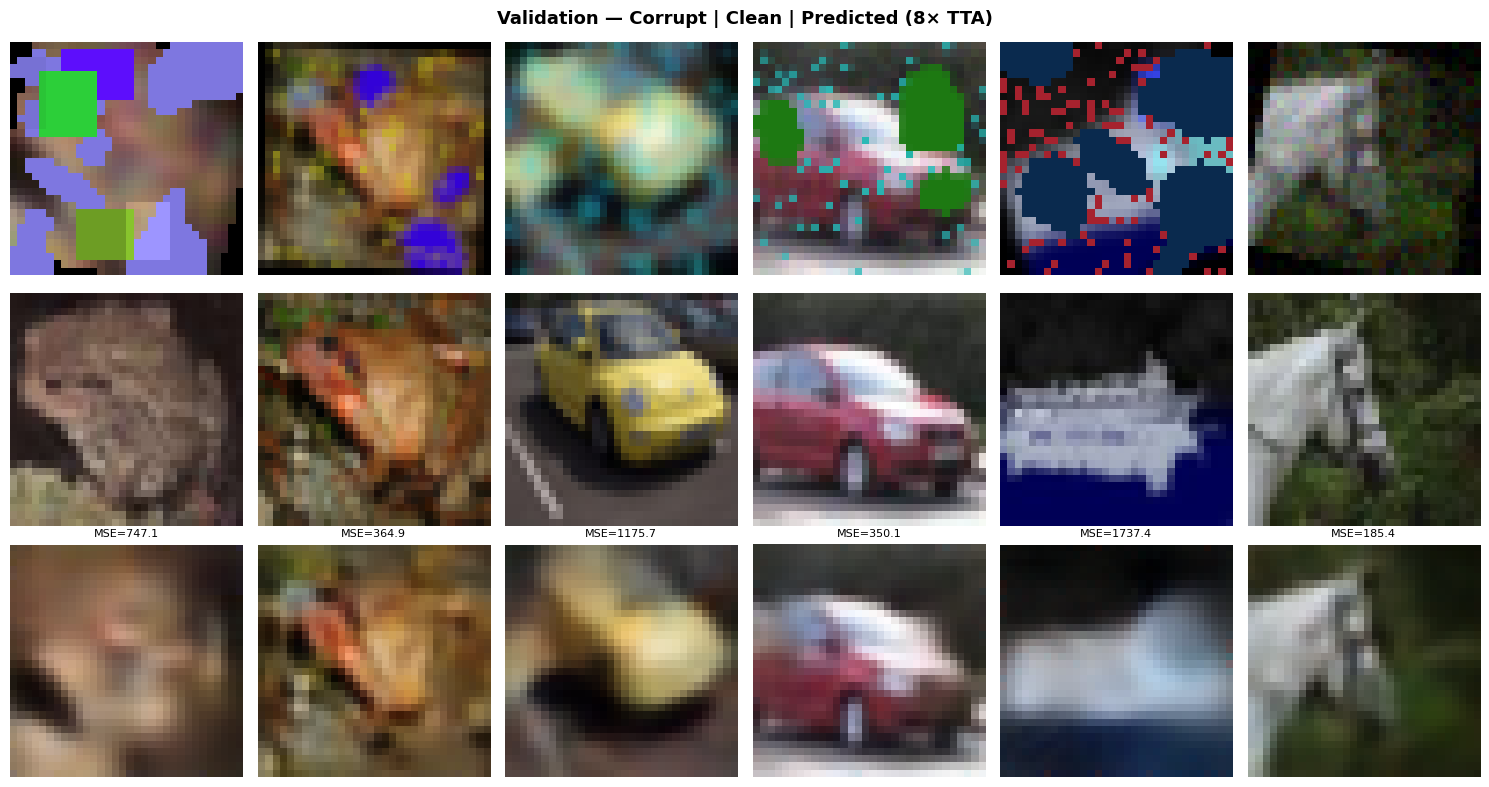

Saved → /kaggle/working/predictions_vis.png


In [16]:
# ── Visualize: Corrupt | Clean | Predicted (val set) ─────────────────────────
num_show = 6
fig, axes = plt.subplots(3, num_show, figsize=(num_show * 2.5, 8))
fig.suptitle("Validation — Corrupt | Clean | Predicted (8× TTA)", fontsize=13, fontweight='bold')
row_labels = ["Corrupted", "Clean (GT)", "Predicted"]

final_model.eval()
val_iter = iter(val_loader)
c_batch, t_batch = next(val_iter)
c_gpu = c_batch[:num_show].to(DEVICE)
t_gpu = t_batch[:num_show].to(DEVICE)

with torch.no_grad():
    pred_batch = predict_tta(final_model, c_gpu)   # (num_show, 3, 32, 32) in [0,1]

c_np    = c_batch[:num_show].permute(0, 2, 3, 1).numpy()
t_np    = t_batch[:num_show].permute(0, 2, 3, 1).numpy()
pred_np = pred_batch.cpu().permute(0, 2, 3, 1).numpy()

for col in range(num_show):
    mse_col = ((pred_np[col] - t_np[col]) ** 2).mean() * (255 ** 2)

    for row, (img, label) in enumerate(zip([c_np[col], t_np[col], pred_np[col]], row_labels)):
        ax = axes[row, col]
        ax.imshow(img.clip(0, 1), interpolation='nearest')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=10, rotation=90, labelpad=4)
    axes[2, col].set_title(f"MSE={mse_col:.1f}", fontsize=8)

plt.tight_layout()
plt.savefig(WORK / 'predictions_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {WORK / 'predictions_vis.png'}")

## 10. Generate Test Predictions + Save Raw TTA Predictions for Ensembling

**Important:** We save the raw TTA predictions as a `.npy` file too, so the main notebook can load them directly and ensemble without re-running inference.

In [17]:
sub_df = pd.read_csv(SAMPLE_SUB_CSV)
test_ids = sub_df['id'].tolist()

test_ds = TestDataset(test_ids, TEST_CORRUPT_DIR)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False,
                         num_workers=CFG['num_workers'], pin_memory=True)

# Save BOTH:
# 1. submission.csv (HWC flattened, [0,255] floats) — matches sample_submission format
# 2. raw_preds_m2.npy  — (N, 3, 32, 32) float32 in [0, 1] range — for ensembling
preds_flat = np.empty((len(test_ids), 3072), dtype=np.float32)
preds_raw  = np.empty((len(test_ids), 3, 32, 32), dtype=np.float32)
ids_out = []
offset = 0

t0 = time.time()
for img_ids, c in test_loader:
    c = c.to(DEVICE, non_blocking=True)
    y = predict_tta(final_model, c)   # (B, 3, 32, 32) in [0, 1]
    y_np = y.cpu().numpy().astype(np.float32)
    bs = y_np.shape[0]
    preds_raw[offset:offset+bs] = y_np

    y_scaled = (y_np * 255.0).clip(0, 255)
    y_hwc = y_scaled.transpose(0, 2, 3, 1).reshape(bs, -1)
    preds_flat[offset:offset+bs] = y_hwc

    ids_out.extend(list(img_ids))
    offset += bs
print(f'Inference time: {time.time() - t0:.1f}s')

assert ids_out == test_ids

# Save submission CSV
pixel_cols = [f'pixel_{i}' for i in range(3072)]
sub_out = pd.DataFrame(preds_flat, columns=pixel_cols)
sub_out.insert(0, 'id', ids_out)
out_path = WORK / 'submission.csv'
sub_out.to_csv(out_path, index=False)
print(f'Submission: {out_path}  shape={sub_out.shape}')

# Save raw TTA predictions for ensembling in main notebook
raw_path = WORK / 'raw_preds_m2.npy'
np.save(raw_path, preds_raw)
print(f'Raw predictions: {raw_path}  shape={preds_raw.shape}  dtype={preds_raw.dtype}')
print(f'Raw value range: [{preds_raw.min():.4f}, {preds_raw.max():.4f}]  (expect roughly [0, 1])')

# Also save test_ids for verification
np.save(WORK / 'test_ids_m2.npy', np.array(test_ids))

Inference time: 86.6s
Submission: /kaggle/working/submission.csv  shape=(12000, 3073)
Raw predictions: /kaggle/working/raw_preds_m2.npy  shape=(12000, 3, 32, 32)  dtype=float32
Raw value range: [0.0000, 1.0000]  (expect roughly [0, 1])


## 11. Summary

In [18]:
print('=' * 60)
print('MODEL 2 TRAINING COMPLETE')
print('=' * 60)
try:
    print(f'Stage 1 best val MSE:   {best_val_mse:.2f}')
    print(f'Stage 2 best val MSE:   {best2:.2f}')
    print(f'Val MSE with 8x TTA:    {total_sq_tta/total_n:.2f}')
except NameError:
    pass
print()
print(f'Submission:       /kaggle/working/submission.csv')
print(f'Raw predictions:  /kaggle/working/raw_preds_m2.npy  (for ensembling)')
print(f'Backup folder:    /kaggle/working/model2_backup/')

MODEL 2 TRAINING COMPLETE

Submission:       /kaggle/working/submission.csv
Raw predictions:  /kaggle/working/raw_preds_m2.npy  (for ensembling)
Backup folder:    /kaggle/working/model2_backup/
